# Homework 2

**Before you start:** Read Chapter 3 Data Visualization and Chapter 4 Dimension Reduction in the textbook.

**Note:** Please make sure your plots are complete and presentable with a title, proper axis names, labels and legends if applicable.

Please enter the code along with your comments in the **TODO** sections.

Please refer to the **Hint** section if you do not know where to start. 

Alternative solutions are welcomed.

## Part 1: Advanced Data Visualization

### Problem 1 ##

**Dataset:** [Mismanaged waste](https://ourworldindata.org/grapher/mismanaged-plastic-waste?tab=chart&time=earliest..latest)

**Introduction:** Jambeck et al. quantified municipal and plastic waste streams from coastal populations in 2010 with projections to the year 2025. The authors define mismanaged and inadequately managed waste as follows: "mismanaged waste is material that is either littered or inadequately disposed. Inadequately disposed waste is not formally managed and includes disposal in dumps or open, uncontrolled landfills, where it is not fully contained. Mismanaged waste could eventually enter the ocean via inland waterways,
wastewater outflows, and transport by wind or tides. "

In [1]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("All packages loaded successfully!")



All packages loaded successfully!


In [3]:
df = pd.read_csv("mismanaged-waste-global-total.csv") 
df.head()

,Entity,Code,Year,Mismanaged waste (% global total) (% of global total)
0,Albania,ALB,2010,0.0933
1,Algeria,DZA,2010,1.6347
2,Angola,AGO,2010,0.1964
3,Anguilla,AIA,2010,0.0002
4,Antigua and Barbuda,ATG,2010,0.0039


In [4]:
df.shape

(186, 4)

In [5]:
df.dtypes

Entity                                                    object
Code                                                      object
Year                                                       int64
Mismanaged waste (% global total) (% of global total)    float64
dtype: object

Convert Date to datetime

In [6]:
df['Year'] = pd.to_datetime(df['Year'],errors='coerce')

In [7]:
df.isna().sum()

Entity                                                   0
Code                                                     0
Year                                                     0
Mismanaged waste (% global total) (% of global total)    0
dtype: int64

In [8]:
df.dtypes

Entity                                                           object
Code                                                             object
Year                                                     datetime64[ns]
Mismanaged waste (% global total) (% of global total)           float64
dtype: object

**TODO1:**

*  Use a choropleth map to present the amount of mismanaged waste by country *(Highlight only the top 5 countries)*
*   The label (hover) should include the country name and percentage of mismanaged waste
*  Interpret your key findings from the map graph
*  Considering the manufacturing volume of each country, is this graph misleading?

In [9]:
df.columns

Index(['Entity', 'Code', 'Year',
       'Mismanaged waste (% global total) (% of global total)'],
      dtype='object')

In [10]:
pip install geopandas

Note: you may need to restart the kernel to use updated packages.


In [11]:
import geopandas as gpd

world = gpd.read_file("/Users/mll/ne_110m_admin_0_countries.shp")
world.columns


Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='object', length=169)

In [12]:
world.isna().sum()
world.dropna(axis=1,inplace=True)

In [13]:
df.rename(columns={'Code':'SOV_A3'},inplace=True)

In [14]:
df.rename(columns={'Mismanaged waste (% global total) (% of global total)':'Mismanaged Waste'},inplace=True)

In [15]:
df.head(2)

,Entity,SOV_A3,Year,Mismanaged Waste
0,Albania,ALB,1970-01-01 00:00:00.000002010,0.0933
1,Algeria,DZA,1970-01-01 00:00:00.000002010,1.6347


In [16]:
world.merge(df,on='SOV_A3',how='left')

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,ADMIN,ADM0_A3,...,NAME_UR,NAME_VI,NAME_ZH,NAME_ZHT,FCLASS_ISO,FCLASS_TLC,geometry,Entity,Year,Mismanaged Waste
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,Fiji,FJI,...,فجی,Fiji,斐济,斐濟,Admin-0 country,Admin-0 country,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ...",Fiji,1970-01-01 00:00:00.000002010,0.1547
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,United Republic of Tanzania,TZA,...,تنزانیہ,Tanzania,坦桑尼亚,坦尚尼亞,Admin-0 country,Admin-0 country,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3...",Tanzania,1970-01-01 00:00:00.000002010,0.1526
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,Western Sahara,SAH,...,مغربی صحارا,Tây Sahara,西撒哈拉,西撒哈拉,Admin-0 dependency,Admin-0 dependency,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948...",NaN,NaT,NaN
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,Canada,CAN,...,کینیڈا,Canada,加拿大,加拿大,Admin-0 country,Admin-0 country,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025...",Canada,1970-01-01 00:00:00.000002010,0.0250
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,United States of America,USA,...,ریاستہائے متحدہ امریکا,Hoa Kỳ,美国,美國,Admin-0 country,Admin-0 country,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312...",NaN,NaT,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,Admin-0 country,1,5,Republic of Serbia,SRB,0,2,Sovereign country,Republic of Serbia,SRB,...,سربیا,Serbia,塞尔维亚,塞爾維亞,Admin-0 country,Admin-0 country,"POLYGON ((18.82982 45.90887, 18.82984 45.90888...",NaN,NaT,NaN
173,Admin-0 country,1,6,Montenegro,MNE,0,2,Sovereign country,Montenegro,MNE,...,مونٹینیگرو,Montenegro,黑山,蒙特內哥羅,Admin-0 country,Admin-0 country,"POLYGON ((20.0707 42.58863, 19.80161 42.50009,...",Montenegro,1970-01-01 00:00:00.000002010,0.0139
174,Admin-0 country,1,6,Kosovo,KOS,0,2,Disputed,Kosovo,KOS,...,کوسووہ,Kosovo,科索沃,科索沃,Unrecognized,Admin-0 country,"POLYGON ((20.59025 41.85541, 20.52295 42.21787...",NaN,NaT,NaN
175,Admin-0 country,1,5,Trinidad and Tobago,TTO,0,2,Sovereign country,Trinidad and Tobago,TTO,...,ٹرینیڈاڈ و ٹوباگو,Trinidad và Tobago,特立尼达和多巴哥,千里達及托巴哥,Admin-0 country,Admin-0 country,"POLYGON ((-61.68 10.76, -61.105 10.89, -60.895...",Trinidad and Tobago,1970-01-01 00:00:00.000002010,0.2954


In [17]:
world.columns

Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'ADMIN', 'ADM0_A3',
       ...
       'NAME_SV', 'NAME_TR', 'NAME_UK', 'NAME_UR', 'NAME_VI', 'NAME_ZH',
       'NAME_ZHT', 'FCLASS_ISO', 'FCLASS_TLC', 'geometry'],
      dtype='object', length=128)

In [18]:
df.columns

Index(['Entity', 'SOV_A3', 'Year', 'Mismanaged Waste'], dtype='object')

In [19]:
world = world.merge(df,on='SOV_A3',how='left')

In [20]:
world.columns

Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'ADMIN', 'ADM0_A3',
       ...
       'NAME_UR', 'NAME_VI', 'NAME_ZH', 'NAME_ZHT', 'FCLASS_ISO', 'FCLASS_TLC',
       'geometry', 'Entity', 'Year', 'Mismanaged Waste'],
      dtype='object', length=131)

In [21]:
df.columns

Index(['Entity', 'SOV_A3', 'Year', 'Mismanaged Waste'], dtype='object')

In [22]:
print(world[['SOV_A3', 'Mismanaged Waste']].head(10))  # See if the column has valid values
print(world['Mismanaged Waste'].isna().sum())  # Count missing values


  SOV_A3  Mismanaged Waste
0    FJI            0.1547
1    TZA            0.1526
2    SAH               NaN
3    CAN            0.0250
4    US1               NaN
5    KA1               NaN
6    UZB               NaN
7    PNG            0.2821
8    IDN           10.1019
9    ARG            0.4955
63


In [23]:
world['Mismanaged Waste'].fillna(0, inplace=True)  # Replace NaN with 0


/var/folders/89/hlf99zq566v5gtf30kyt2gp40000gn/T/ipykernel_8681/3151066984.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  world['Mismanaged Waste'].fillna(0, inplace=True)  # Replace NaN with 0


In [24]:
print(world['Mismanaged Waste'].isna().sum())

0


In [25]:
top5countries = df.nlargest(5,'Mismanaged Waste')

In [26]:
world1 = world.merge(top5countries,on='SOV_A3',how='inner')

In [27]:
top5new = world.nlargest(5,'Mismanaged Waste')

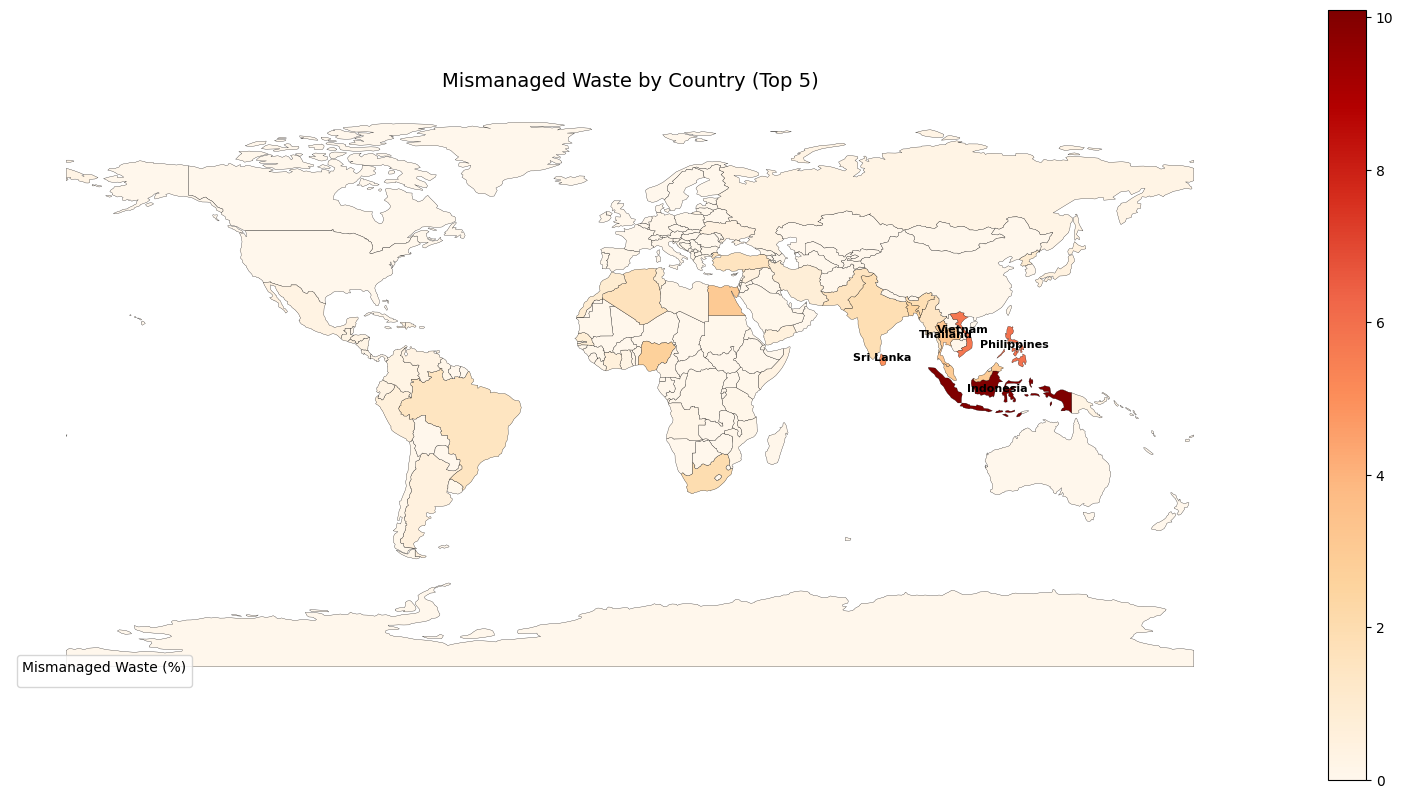

In [28]:
fig, ax = plt.subplots(figsize=(20,10))
world.plot(column="Mismanaged Waste", cmap="OrRd", linewidth=0.2, edgecolor="black", legend=True, ax=ax)


for i,row in top5new.iterrows():
    if pd.notnull(row['Mismanaged Waste']):
        centroid = row.geometry.centroid
        ax.annotate(text=row['NAME'],xy=(centroid.x,centroid.y),
                    fontsize=8,ha='center',color='black',weight='bold')
        
ax.set_title("Mismanaged Waste by Country (Top 5)", fontsize=14)
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)


handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Mismanaged Waste (%)", loc='lower left')

plt.show()

**Hint:** 

* The variable "code" contains [three letters ISO country codes](https://en.wikipedia.org/wiki/ISO_3166-1_alpha-3). 
* [Use the built-in country code to create a choropleth map.](https://plotly.com/python/choropleth-maps/#using-builtin-country-and-state-geometries)



### Problem 2 ##

**Dataset:** [Plastic disposal dataset](https://ourworldindata.org/plastic-pollution)

**Information:** Plastic disposal dataset methods shows how has global plastic waste disposal method changed over time. In the chart we see the share of global plastic waste that is discarded, recycled or incinerated from 1980 through to 2015.


In [29]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [30]:
#Load the dataset
df2 = pd.read_excel("activity.xlsx") 
df2.head()

,year,Value,Type
0,1960,88.1,Generation
1,1960,NaN,Composting*
2,1960,5.6,Recycling
3,1960,0.0,Combustion with energy recovery
4,1960,82.5,Landfilling and other disposal


**TODO1:**
*  Use an animated bar chart to indicate the change of trash disposal method through the years
*  Interpret your key findings from the graph


In [31]:
type_count = df2['Type'].value_counts()
print(f"Number of unique types: {type_count}")

Number of unique types: Type
Generation                         10
Composting*                        10
Recycling                          10
Combustion with energy recovery    10
Landfilling and other disposal     10
Name: count, dtype: int64


In [32]:
pip install --upgrade nbformat


Note: you may need to restart the kernel to use updated packages.


In [33]:
import plotly.express as px

fig = px.bar(df2,x='year',y='Value',color = 'Type',animation_frame='year',
             labels={'Value':'Amount','Type':'Disposal Method'},
             title='Change of trash Disposal over the Y')

fig.show()

**Hint:** [Animated Bar Charts with Plotly Express](https://plotly.com/python/animations/#animated-bar-charts-with-plotly-express)




**TODO2:**
*  Suggest and show a better way to visualize the  data (choose the most approporiate visualization for this use case)

We can use a Stacked Bar Chart as an alternative to Animated Bar Chart

In [34]:
fig1 = px.area(df2,x='year',y='Value',color='Type',labels={'Value':'Amount','Type':'Disposal Method'},
               title='Change of Trash Disposal over the years')
fig1.show()

### Problem 3 ##

**Dataset:** [Global Fortune 500](https://www.kaggle.com/edgarhuichen/fortune-global-500)

**Introduction:** Fortune Global 500 List is a list of largest corporations worldwide which are measured by their total fiscal year revenues. Companies rankings sorted by total revenues for their respective fiscal years ended on or before March 31 of the relevant year.

In [35]:
#Upgrade the package "plotly" before you start to avoid future syntax error
#You only need to upgrade it once
!pip install plotly --upgrade


In [36]:
#Import packages
import pandas as pd
import numpy as np
import plotly.express as px

#Load the dataset
df = pd.read_csv("Global Fortune 500.csv") 
df.head()

,Rank,Company Name,Country,Number of Employees,Previous Rank,Revenues($millions),Revenue Change,Profits($millions),Profit Change,Assets($millions),Unnamed: 10,Unnamed: 11
0,1,Walmart,USA,"2,300,000",1,485873,0.80%,13643,-7.20%,198825,NaN,NaN
1,2,State Grid,China,"926,067",2,315199,-4.40%,9571.3,-6.20%,489838,NaN,NaN
2,3,Sinopec Group,China,"713,288",4,267518,-9.10%,1257.9,-65.00%,310726,NaN,NaN
3,4,China National Petroleum,China,"1,512,048",3,262573,-12.30%,1867.5,-73.70%,585619,NaN,NaN
4,5,Toyota Motor,Japan,"364,445",8,254694,7.70%,16899.3,-12.30%,437575,NaN,NaN


**TODO1:**
*  Build a treemap of the companies with "country" as the first hierarchy and "company" as the second hierarchy (Only show top 5 businesses for each country)
*  The size of each block should indicate the corresponding company's revenue
*  Interpret your key findings from the treemap

In [39]:
df_top5 = df.groupby('Country', group_keys=False).apply(lambda x: x.nlargest(5, 'Revenues($millions)')).reset_index()



/var/folders/89/hlf99zq566v5gtf30kyt2gp40000gn/T/ipykernel_8681/3335987191.py:1: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [40]:
import plotly.express as px

df_top5 = df.groupby('Country', group_keys=False).apply(lambda x: x.nlargest(5, 'Revenues($millions)')).reset_index()

fig = px.treemap(df_top5, path=['Country', 'Company Name'], values='Revenues($millions)', 
                 color='Revenues($millions)', hover_data=['Revenues($millions)'],
                 color_continuous_scale='Blues', title='Top 5 Companies per Country')

fig.update_traces(root_color='blue')
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig.show()


/var/folders/89/hlf99zq566v5gtf30kyt2gp40000gn/T/ipykernel_8681/2126872377.py:3: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



Inference of the TreeMap:
1) Walmart is the biggest revenue generating company on the planet.
2) China and the US have some of the biggest companies in the world.

**Hint:** [Build a treemap with Plotly](https://plotly.com/python/treemaps/)




### Problem 4 ##

**Dataset:** [Air Quality](https://archive.ics.uci.edu/ml/datasets/Air+Quality)

**Introduction:** The dataset contains 9358 instances of hourly averaged responses from an array of 5 metal oxide chemical sensors embedded in an Air Quality Chemical Multisensor Device. The device was located on the field in a significantly polluted area, at road level,within an Italian city. Data were recorded from March 2004 to February 2005 (one year)representing the longest freely available recordings of on field deployed air quality chemical sensor devices responses. Ground Truth hourly averaged concentrations for CO, Non Metanic Hydrocarbons, Benzene, Total Nitrogen Oxides (NOx) and Nitrogen Dioxide (NO2) and were provided by a co-located reference certified analyzer. Evidences of cross-sensitivities as well as both concept and sensor drifts are present as described in De Vito et al., Sens. And Act. B, Vol. 129,2,2008 (citation required) eventually affecting sensors concentration estimation capabilities. Missing values are tagged with -200 value.

In [42]:
#Import required libraries
import scipy.stats as stats
from sklearn import preprocessing


#Load the dataset
df1 = pd.read_excel("Air Quality.xlsx") 
df1.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


**TODO1:**
*  Plot a correlation heatmap for the Air Quality dataset
*  Interpret your key findings from the correlation heatmap (value of correlation should be displayed in the heatmap)

In [43]:
df1.dtypes

Date             datetime64[ns]
Time                     object
CO(GT)                  float64
PT08.S1(CO)             float64
NMHC(GT)                  int64
C6H6(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
dtype: object

In [44]:
df1['Time'] = df1['Time'].astype(str)

In [45]:
df1['DateTime'] = pd.to_datetime(df1['Date'].dt.strftime('%Y-%m-%d') + ' ' + df1['Time'])
df1['DateTime_Float'] = df1['DateTime'].astype('int64') / 1e9


In [46]:
df1.dtypes

Date              datetime64[ns]
Time                      object
CO(GT)                   float64
PT08.S1(CO)              float64
NMHC(GT)                   int64
C6H6(GT)                 float64
PT08.S2(NMHC)            float64
NOx(GT)                  float64
PT08.S3(NOx)             float64
NO2(GT)                  float64
PT08.S4(NO2)             float64
PT08.S5(O3)              float64
T                        float64
RH                       float64
AH                       float64
DateTime          datetime64[ns]
DateTime_Float           float64
dtype: object

In [47]:
df1.drop(columns=['Date','Time','DateTime'],inplace=True)

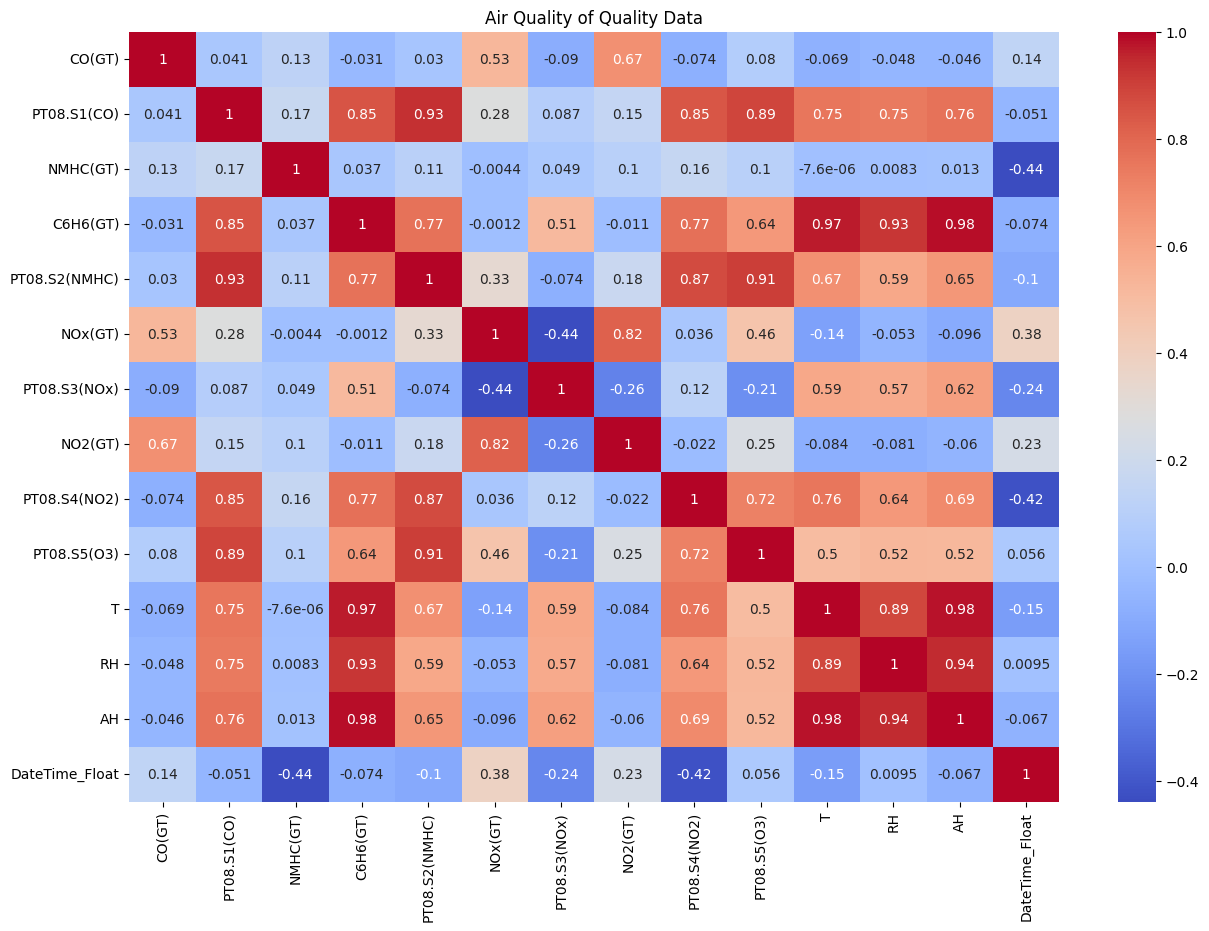

In [48]:
plt.figure(figsize=(15,10))
sns.heatmap(df1.corr(),annot=True,cmap='coolwarm')
plt.title('Air Quality of Quality Data')
plt.show()

Inference of the HeatMap:
1) The Dark Red and Dark Blue columns show high correlation between variables
2) The Lighter Shade of columns represent weak correlation between them.

**Hint:** [Build a heatmap with Seaborn](https://seaborn.pydata.org/generated/seaborn.heatmap.html)

## Part 2: Dimension Reduction

### Problem 5

please consider the **iris dataset**:


In [49]:
#Import the built-in dataset (Wine recognition) for this problem
import sklearn
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
print(sklearn.datasets.load_iris().DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [50]:
#laod the dataset
iris = datasets.load_iris()
X = pd.DataFrame(iris.data)
X.head()

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [51]:
# laod the vector of target variable
y = iris.target

In [52]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

**TODO1:**

*  Determine first two principal component scores for the data set with eigenvalues and eigenvectors on the RAW data (without standardization). 

*  Note that you are expected to perform matrix multipication, eigen value calculation **only** with the package Numpy, and sorted eigenvalues and eigenvectors in descending order (i.e. $\lambda_{0} \geq \lambda_{1} \geq \lambda{2} \geq ... \geq \lambda_{n}$ so do the eigenvectors).

In [53]:
cov_matrix = np.cov(X.T)

In [54]:
eigenvalues,eigenvectors = np.linalg.eig(cov_matrix)
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:,sorted_indices]

In [55]:
X_pca = X.dot(sorted_eigenvectors[:,:2])
print("First Two Components")
print(X_pca.head())


First Two Components
          0         1
0  2.818240 -5.646350
1  2.788223 -5.149951
2  2.613375 -5.182003
3  2.757022 -5.008654
4  2.773649 -5.653707


In [56]:
print("Eigen Values:")
print(sorted_eigenvalues)
print("EigenValues:")
print(sorted_eigenvectors)

Eigen Values:
[4.22824171 0.24267075 0.0782095  0.02383509]
EigenValues:
[[ 0.36138659 -0.65658877 -0.58202985  0.31548719]
 [-0.08452251 -0.73016143  0.59791083 -0.3197231 ]
 [ 0.85667061  0.17337266  0.07623608 -0.47983899]
 [ 0.3582892   0.07548102  0.54583143  0.75365743]]


**Hint:** 

1. [Eigen value calculation with Numpy](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html)

2. [Sorting a Numpy array](https://sparkbyexamples.com/python/numpy-sort-arrays-examples/#:~:text=By%20Sorting%20a%20NumPy%20array,%5B12%208%206%205%5D.)

**TODO2:**

*  Perform the data standardization on the data without using any buit-in functions.

*  Determine the first two principal component scores with eigenvaues and eigenvectors on the standardized data by updataing your code form **TODO1**. (i.e. your code from **TODO** one should not be changed; you should only add a cell of code for standardization.)

In [57]:
X_standardized = (X-X.mean())/ X.std()


In [58]:
cov_matrix_std = np.cov(X_standardized.T)
eigenvalues_std,eigenvectors_std = np.linalg.eig(cov_matrix_std)
sorted_indices_std = np.argsort(eigenvalues_std)[::-1]
sorted_eigenvalues_std = eigenvalues_std[sorted_indices_std]
sorted_eigenvectors_std = eigenvectors_std[:,sorted_indices_std]

In [59]:
X_pca_std = X_standardized.dot(sorted_eigenvectors_std[:,:3])

In [60]:
print("First 2 PCA Components are (with standarization): ")
print(X_pca_std.head())

First 2 PCA Components are (with standarization): 
          0         1         2
0 -2.257141 -0.478424 -0.127280
1 -2.074013  0.671883 -0.233826
2 -2.356335  0.340766  0.044054
3 -2.291707  0.595400  0.090985
4 -2.381863 -0.644676  0.015686


In [61]:
print("EigenValues( standarized data) : ")
print(sorted_eigenvalues_std)
print("EigenVectors (standardized data)")
print(sorted_eigenvectors_std)

EigenValues( standarized data) : 
[2.91849782 0.91403047 0.14675688 0.02071484]
EigenVectors (standardized data)
[[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


In [62]:
print(eigenvectors == sorted_eigenvalues_std)

[[False False False False]
 [False False False False]
 [False False False False]
 [False False False False]]


**TODO3:**

*  Use the built-in function called `PCA()` on the raw data to calculate the first two principal components.

*  For each of the components, indentify the explained variance, proportion variance, and cummulative proportion of variance.

* Compare your result with **TODO1**, are they same? (You might expect that you will have the same result wilth **TODO1**. However, `PCA()` function automatically does `x-mean()` transformation. Therefore, do not worry that your result from this one is different than the result performed from **TODO1**.)

**Hint**: 

* [PCA Python](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

In [63]:
X_standardized1 = (X-X.mean())/X.std()
pca = PCA(n_components=3)
X_pca1 = pca.fit_transform(X_standardized1)

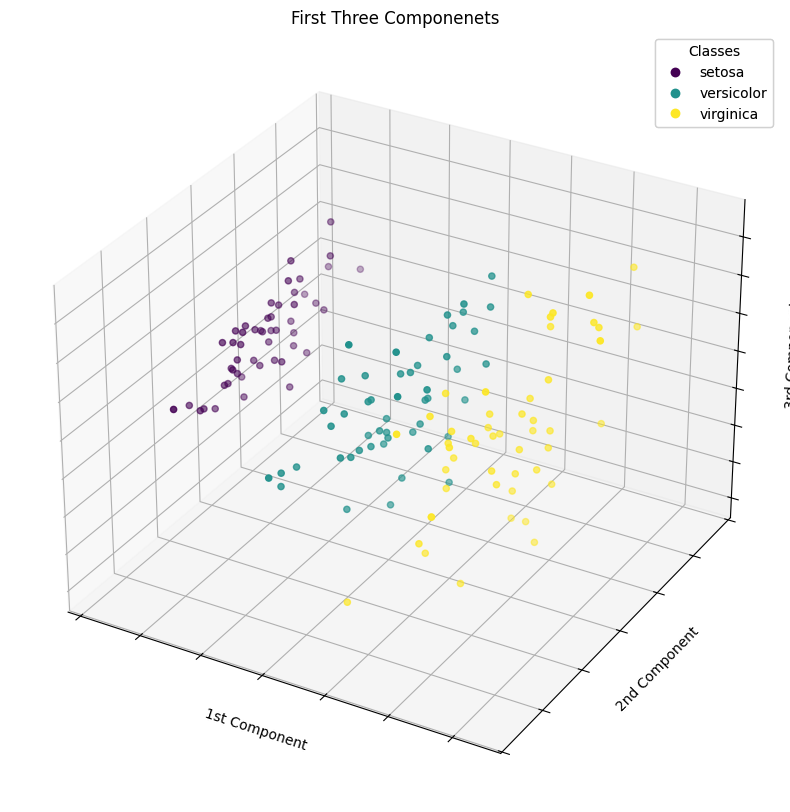

In [64]:
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111,projection='3d')

scatter = ax.scatter(
    X_pca1[:,0],
    X_pca1[:,1],
    X_pca1[:,2],
    c=iris.target,
    cmap='viridis',
)

ax.set_title("First Three Componenets")
ax.set_xlabel('1st Component')
ax.set_ylabel('2nd Component')
ax.set_zlabel('3rd Component')

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

legend1 = ax.legend(scatter.legend_elements()[0],
                    iris.target_names.tolist(),
                    loc = 'upper right',title='Classes')

ax.add_artist(legend1)
plt.show()

**TODO4:**

*  Use the built-in function called `preprocessing.StandardScaler` and `PCA` to calculate the first two principal components. 

*  For each of the components, determine the explained variance, propotion variance, and cummulative proportion of variance.

* Compare your result with **TODO2**, are they same?

**Hint**: [Data Standardization in Python](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

In [65]:
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

In [66]:
pca = PCA(n_components=3)
X_pca2 = pca.fit_transform(X_scaled)


In [67]:
explained_variance = pca.explained_variance_
proportion_variance = pca.explained_variance_ratio_
noise_variance = pca.noise_variance_
cummulative_variance = np.cumsum(proportion_variance)
print(explained_variance)

[2.93808505 0.9201649  0.14774182]


In [68]:
print(proportion_variance)

[0.72962445 0.22850762 0.03668922]


In [69]:
print(cummulative_variance)

[0.72962445 0.95813207 0.99482129]


In [70]:
print(X_scaled == X_standardized)

         0      1      2      3
0    False  False  False  False
1    False  False  False  False
2    False  False  False  False
3    False  False  False  False
4    False  False  False  False
..     ...    ...    ...    ...
145  False  False  False  False
146  False  False  False  False
147  False  False  False  False
148  False  False  False  False
149  False  False  False  False

[150 rows x 4 columns]


**TODO5:**

*  Integrate from **TODO1** to **TODO4**, why is it important to standardize(normalize) variables before perfroming PCA

*  Plot the records on 2D plane defined by the first two PCA components calcualted with standardized data and dffierentiate them using by **target** (i.e. $y$).

*  Make some meaningful interpretation about the plot.

In [71]:
X1 = pd.DataFrame(iris.data)
X1.head()

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [72]:
y1 = iris.target
y1

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [73]:
scaler = StandardScaler()
X_scaled_final = scaler.fit_transform(X1)

In [74]:
pca = PCA(n_components=3)
X_pca_final = pca.fit_transform(X_scaled_final)


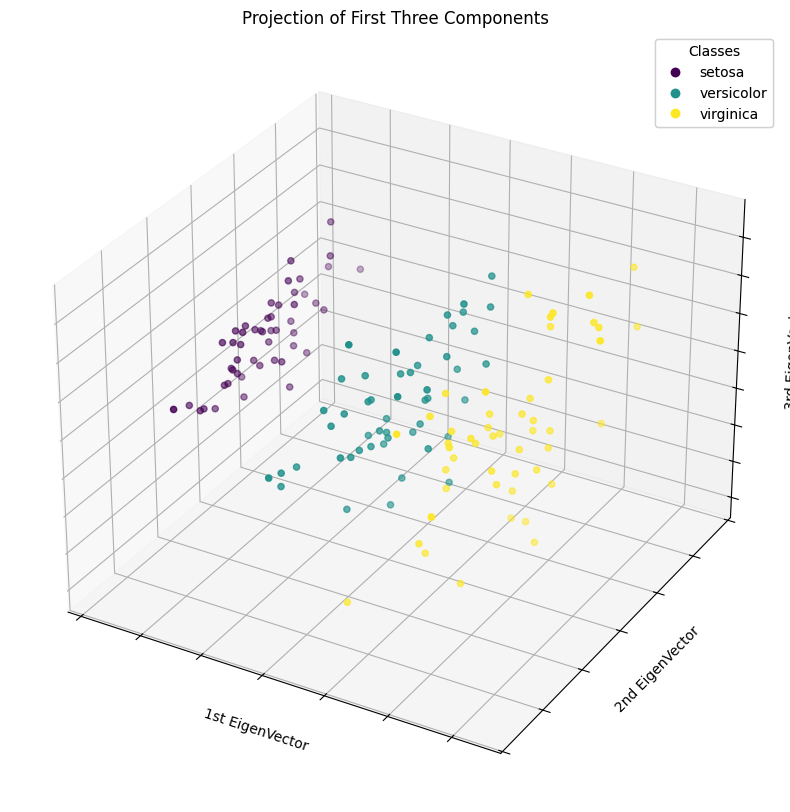

In [75]:
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(
    X_pca_final[:,0],
    X_pca_final[:,1],
    X_pca_final[:,2],
    c=iris.target,
    cmap='viridis'
)

ax.set_title('Projection of First Three Components')
ax.set_xlabel('1st EigenVector')
ax.set_ylabel("2nd EigenVector")
ax.set_zlabel("3rd EigenVector")
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

legend2 =ax.legend(scatter.legend_elements()[0],
           iris.target_names.tolist(),
           loc='upper right',
           title ='Classes')

ax.add_artist(legend2)
plt.show()

### Problem 6

**Dataset:** Life Expectancy

**Introduction:** The above dataset gives life expectancy related data for 37 countries in2014. 

Consider only the following variables in your analysis: 'GDP', 'Income composition of resources', 'Schooling', and 'Total expenditure'.

In [76]:
df5 = pd.read_csv('Life Expectancy.csv')
df5.head(2)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2014,Developing,59.9,271,64,0.01,73.523582,62.0,492,...,58,8.18,62,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
1,Australia,2014,Developed,82.7,6,1,9.71,10769.363050,91.0,340,...,92,9.42,92,0.1,62214.691200,2346694.0,0.6,0.6,0.936,20.4


In [77]:
columns_to_keep = ['GDP','Income composition of resources','Schooling','Total expenditure','Country','Status']
df_select = df5[columns_to_keep].dropna()

**TODO1:**

* Standardize the numeric variables in the given data frame
* Run MDS() (Multi Dimensional Scaling) on the standardized data 
  - **Hint:** n_components = 2
* Plot data points on a 2D plane defined by the first two components
* Use color to differentiate the statues of each country with legend
* Use text label to specify the country name for each point
* Comment your findings from the graph

**Hint:**  [MDS Python](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.MDS.html)

In [78]:
scaler = StandardScaler()
df_select_scaled = scaler.fit_transform(df_select[['GDP','Income composition of resources','Schooling','Total expenditure']])

In [79]:
from sklearn.manifold import MDS

mds = MDS(n_components=2,random_state=42,dissimilarity='euclidean')
mds_results = mds.fit_transform(df_select_scaled)


In [80]:
df_mds = pd.DataFrame(mds_results,columns=['MDS1','MDS2'])
df_mds['Country'] = df_select['Country'].values
df_mds['Status'] = df_select['Status'].values

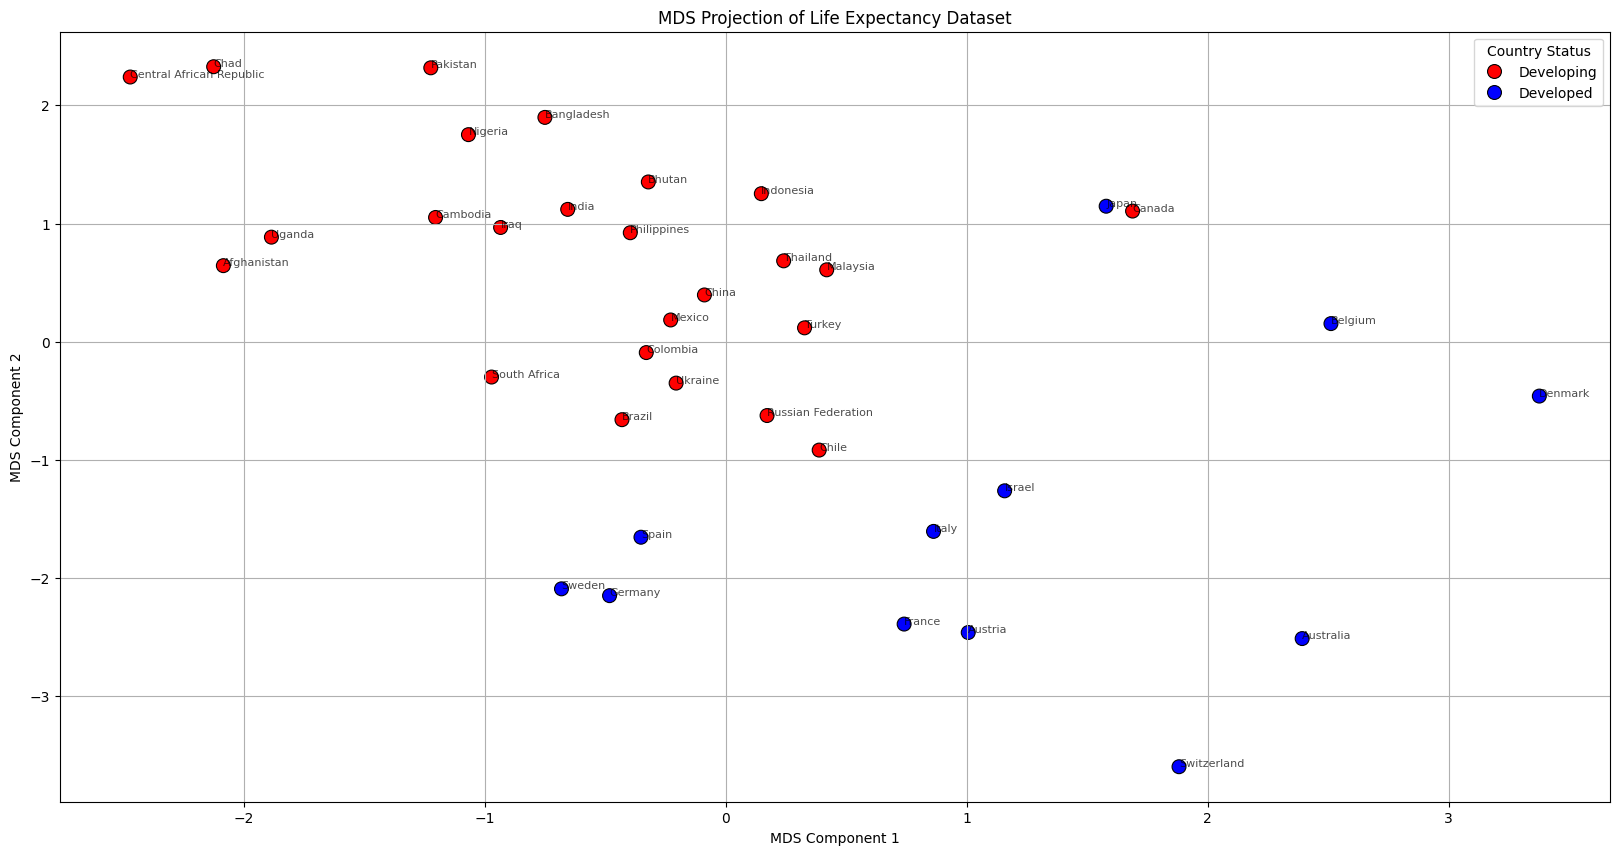

In [81]:
plt.figure(figsize=(20,10))
sns.scatterplot(x='MDS1', y='MDS2', hue='Status', data=df_mds, palette={'Developed': 'blue', 'Developing': 'red'}, s=100, edgecolor='black')

for i,row in df_mds.iterrows():
    plt.text(row['MDS1'], row['MDS2'], row['Country'], fontsize=8, alpha=0.7)

plt.title('MDS Projection of Life Expectancy Dataset')
plt.xlabel('MDS Component 1')
plt.ylabel('MDS Component 2')
plt.legend(title="Country Status")
plt.grid(True)
plt.show()

### Problem 7

Dataset: Game of thrones Books

Introduction: If you haven't heard of Game of Thrones, then you must be really good at hiding. Game of Thrones is the hugely popular television series by HBO based on the (also) hugely popular book series A Song of Ice and Fire by George R.R. Martin. You need to analyze the co-occurrence network of the characters in the Game of Thrones books. Here, two characters are considered to co-occur if their names appear in the vicinity of 15 words from one another in the books.

This dataset (5 files attached in zip file) constitutes a network and is given as a text file describing the edges between characters, with some attributes attached to each edge.

Loading the required libraries

In [83]:
pip install networkx

  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
Using cached networkx-3.4.2-py3-none-any.whl (1.7 MB)
Note: you may need to restart the kernel to use updated packages.


In [84]:
pip install pyvis

  Using cached pyvis-0.3.2-py3-none-any.whl.metadata (1.7 kB)
  Using cached jsonpickle-4.0.1-py3-none-any.whl.metadata (8.2 kB)
Using cached pyvis-0.3.2-py3-none-any.whl (756 kB)
Using cached jsonpickle-4.0.1-py3-none-any.whl (46 kB)
Note: you may need to restart the kernel to use updated packages.


In [85]:
import networkx as nx
from pyvis.network import Network
from math import gcd


**TODO1:**

- Load data for the all the books of Game of Thrones (Merge all files into one and create a dataframe)
- Select only the rows which has weight more than 10

In [87]:
dfb1 = pd.read_csv('book1.csv')
dfb1 = dfb1.loc[dfb1['weight'] > 10]

In [88]:
dfb2 =pd.read_csv('book2.csv')
dfb3 =pd.read_csv('book3.csv')
dfb4 =pd.read_csv('book4.csv')
dfb5 =pd.read_csv('book5.csv')


def weightcleareance(df,col):
    df = df.loc[df[col] > 10]
    return df

In [89]:
weightcleareance(dfb2,'weight')
weightcleareance(dfb3,'weight')
weightcleareance(dfb4,'weight')
weightcleareance(dfb5,'weight')



,Source,Target,Type,weight,book
1,Aegon-Targaryen-(son-of-Rhaegar),Daenerys-Targaryen,undirected,11,5
4,Aegon-Targaryen-(son-of-Rhaegar),Haldon,undirected,14,5
6,Aegon-Targaryen-(son-of-Rhaegar),Jon-Connington,undirected,16,5
10,Aegon-Targaryen-(son-of-Rhaegar),Rolly-Duckfield,undirected,11,5
11,Aegon-Targaryen-(son-of-Rhaegar),Tyrion-Lannister,undirected,23,5
...,...,...,...,...,...
751,Tyrion-Lannister,Tywin-Lannister,undirected,18,5
753,Tyrion-Lannister,Yandry,undirected,15,5
754,Tyrion-Lannister,Yezzan-zo-Qaggaz,undirected,17,5
755,Tyrion-Lannister,Ysilla,undirected,11,5


In [90]:
print(dfb5.shape)

(760, 5)


In [91]:
dfs = [dfb1,dfb2,dfb3,dfb4,dfb5]
dfs = [df for df in dfs if df is not None]
merged_df = pd.concat(dfs,ignore_index=True)

In [92]:
merged_df.head()

,Source,Target,Type,weight,book
0,Aemon-Targaryen-(Maester-Aemon),Jeor-Mormont,Undirected,13,1.0
1,Aemon-Targaryen-(Maester-Aemon),Jon-Snow,Undirected,34,1.0
2,Aerys-II-Targaryen,Robert-Baratheon,Undirected,12,1.0
3,Aggo,Daenerys-Targaryen,Undirected,11,1.0
4,Alliser-Thorne,Jon-Snow,Undirected,32,1.0


In [93]:
merged_df.shape

(3400, 5)

**TODO2:**
Load the dataframe as networkx graph

Hint: [Network analysis in python](https://networkx.org/documentation/stable/reference/generated/networkx.convert_matrix.from_pandas_edgelist.html)

In [94]:
G = nx.from_pandas_edgelist(merged_df,source="Source",target="Target")


In [95]:
print("No of unique characters:", len(G.nodes))
print("No of connections:", len(G.edges))

No of unique characters: 750
No of connections: 2506


**TODO3:**

Create viz network
Hint: [Use Pyvis](https://pyvis.readthedocs.io/en/latest/)

PS: If you are unable to view the network, export it to a html file and upload the html file along with the homework submissions in canvas.

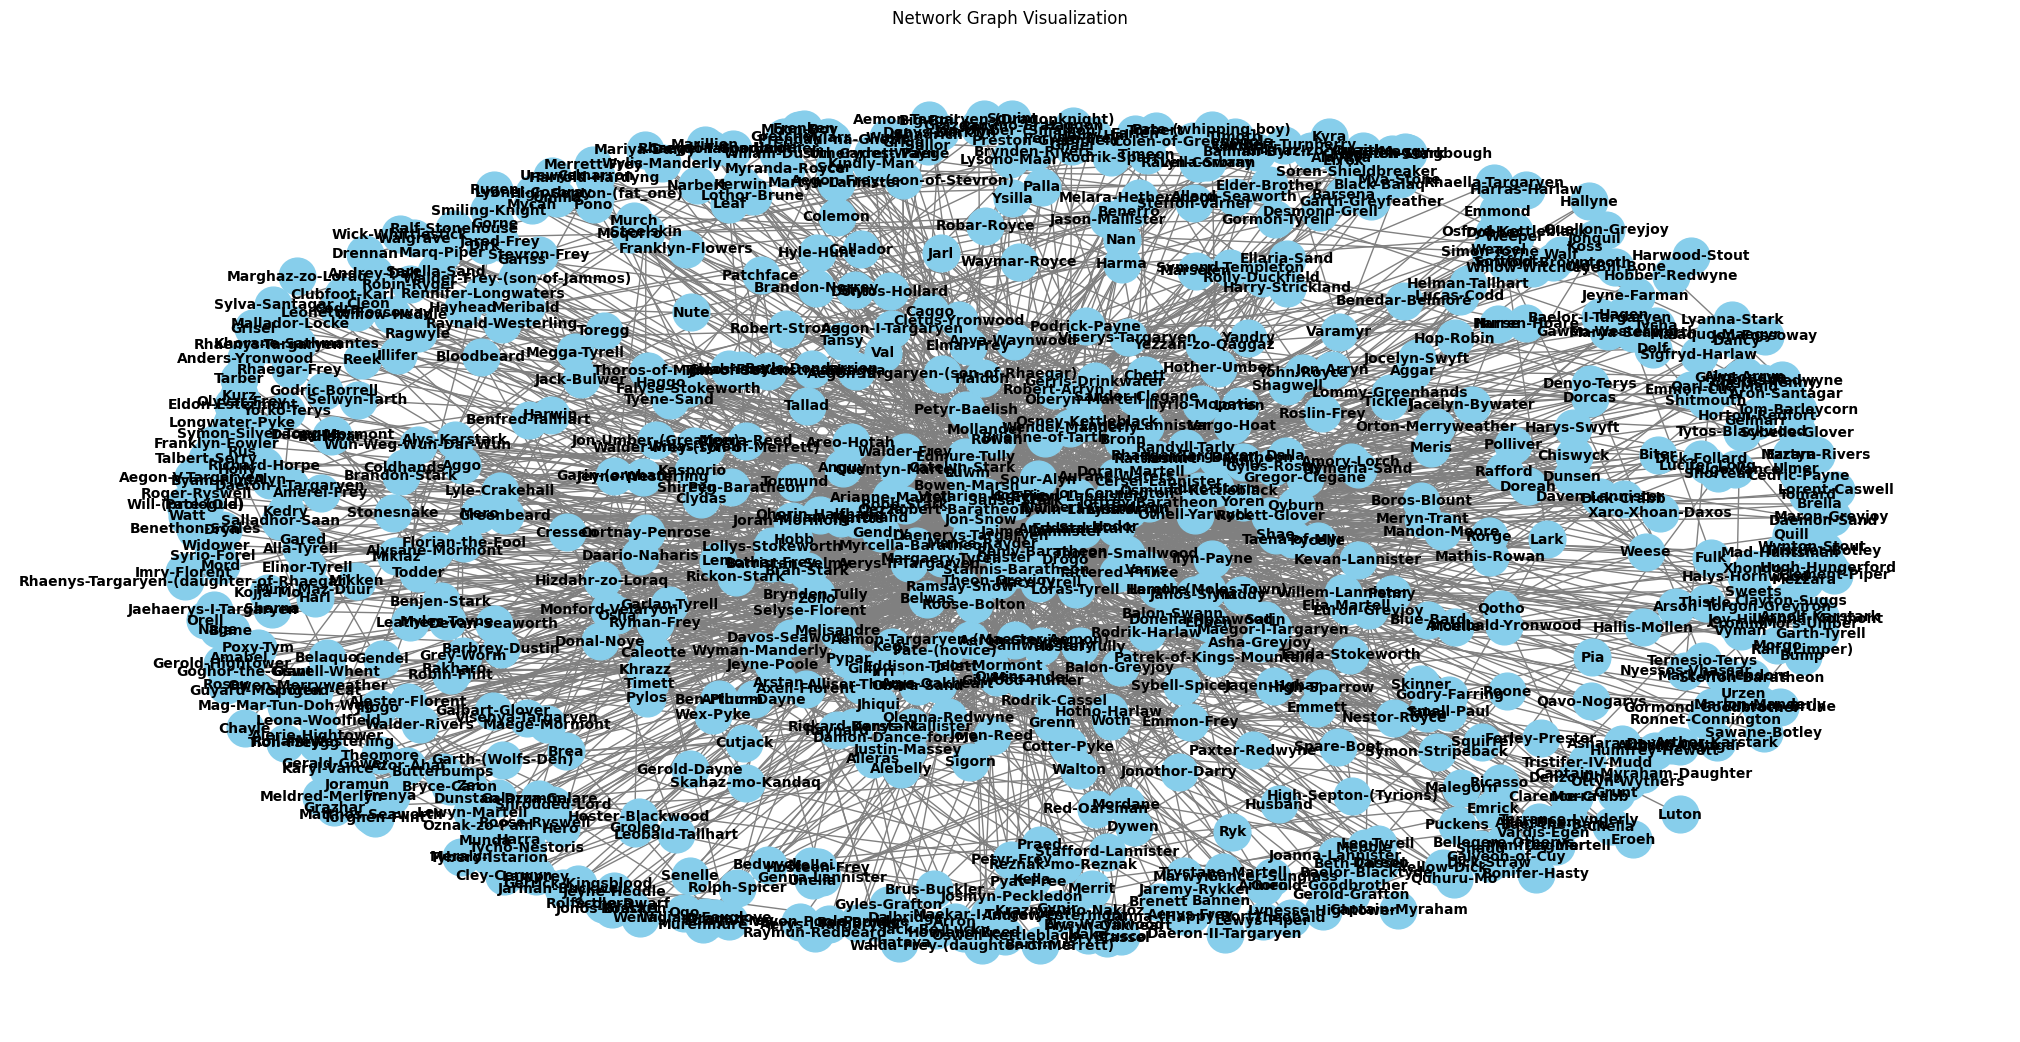

In [96]:
plt.figure(figsize=(20,10))
pos = nx.spring_layout(G,seed=42,k=0.5)
nx.draw(G,pos,with_labels=True,node_color='skyblue',edge_color = 'gray',node_size=700,font_size=10,font_weight='bold')
plt.title("Network Graph Visualization")
plt.show()

In [97]:
net = Network(notebook=False,height="800px",width="100%",bgcolor="#22222",font_color="white")
net.from_nx(G)
net.save_graph("network_graph.html")
print("HTML File saved succesfully in directory")

HTML File saved succesfully in directory
